# Tox21 Drug Toxicity Prediction — `new_tox.ipynb`

এই notebook টি research-style Tox21 toxicity prediction workflow। এখানে preprocessing আগের মতোই রাখা হয়েছে, কিন্তু latest requirement অনুযায়ী model set update করা হয়েছে।

**Main setup:** 75% train / 25% test split, 3-fold cross-validation, missing-label masking, imbalance-aware training, ML + Deep Learning + Hybrid models।

## Paper-informed model choices

এই notebook-এর model selection আগের uploaded papers থেকে নেওয়া ধারণার উপর based:

- **DeepTox-style multitask DNN:** 12 labels একসাথে learn করে।
- **Multitask CapsNet:** imbalanced sparse positive class ধরতে promising।
- **SMILES Transformer / ChemBERTa:** raw SMILES থেকে contextual chemical representation learn করে।
- **GNN / GCN-GAT style:** molecule কে graph হিসেবে শেখে।
- **DenseNet121 2D molecule image:** 2D chemical image থেকে visual structural representation শেখে।
- **Hybrid:** DenseNet/CapsNet embeddings + SVM RBF বা Random Forest।

## 1. Library setup and configuration

প্রথমে প্রয়োজনীয় libraries load করা হবে। Heavy deep learning models GPU থাকলে দ্রুত run করবে।

In [15]:
import os, gc, math, json, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_PATH = '/mnt/data/tox21.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'tox21.csv'

TOX21_ENDPOINTS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

CONFIG = {
    'test_size': 0.25,
    'n_splits_cv': 3,
    'morgan_bits': 2048,
    'morgan_radius': 2,
    'batch_size': 64,
    'deep_epochs': 12,
    'dense_image_size': 224,
    'run_heavy_deep_models': True,   # GPU না থাকলে False করে দ্রুত run করা যাবে
    'run_chemberta': True,           # internet/model cache না থাকলে automatic skip হবে
    'run_densenet': True,            # torchvision/tensorflow না থাকলে automatic skip হবে
    'run_gnn': True
}

print('Configuration loaded')
print(json.dumps(CONFIG, indent=2))

Configuration loaded
{
  "test_size": 0.25,
  "n_splits_cv": 3,
  "morgan_bits": 2048,
  "morgan_radius": 2,
  "batch_size": 64,
  "deep_epochs": 12,
  "dense_image_size": 224,
  "run_heavy_deep_models": true,
  "run_chemberta": true,
  "run_densenet": true,
  "run_gnn": true
}


## 2. Load Tox21 dataset

Tox21 CSV load করা হবে এবং 12 endpoint numeric target হিসেবে রাখা হবে। Missing label `NaN` হিসেবেই থাকবে।

In [17]:
df = pd.read_csv(DATA_PATH)

df_raw = pd.read_csv(DATA_PATH)
print("Using dataset:", DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Using dataset: tox21.csv
Raw shape: (7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [24]:
TARGET_COLS = [c for c in df_raw.columns if c not in ["mol_id", "smiles"]]
print("Number of Tox21 endpoints:", len(TARGET_COLS))
print(TARGET_COLS)

for col in TARGET_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

Number of Tox21 endpoints: 12
['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


## 3. Dataset imbalance and missing-label summary

এখানে endpoint-wise toxic/non-toxic/missing label distribution দেখা হবে।

In [27]:
def make_endpoint_summary(df, target_cols):
    rows = []
    total_n = len(df)
    for col in target_cols:
        y = df[col]
        y_labeled = y.dropna().astype(int)
        n_pos = int((y_labeled == 1).sum())
        n_neg = int((y_labeled == 0).sum())
        n_missing = int(y.isna().sum())
        labeled = int(len(y_labeled))
        pos_rate = 100 * n_pos / max(labeled, 1)
        miss_rate = 100 * n_missing / max(total_n, 1)
        ratio = n_neg / max(n_pos, 1)
        rows.append({
            "Endpoint": col,
            "Labeled": labeled,
            "Toxic (1)": n_pos,
            "Non-Toxic (0)": n_neg,
            "Missing": n_missing,
            "Missing %": miss_rate,
            "Pos Rate %": pos_rate,
            "Imbalance": f"{ratio:.1f} : 1",
            "RatioValue": ratio,
        })
    return pd.DataFrame(rows)

endpoint_summary = make_endpoint_summary(df_raw, TARGET_COLS)
endpoint_summary_display = endpoint_summary.drop(columns=["RatioValue"]).copy()
endpoint_summary_display["Missing %"] = endpoint_summary_display["Missing %"].round(1)
endpoint_summary_display["Pos Rate %"] = endpoint_summary_display["Pos Rate %"].round(1)
endpoint_summary_display

,Endpoint,Labeled,Toxic (1),Non-Toxic (0),Missing,Missing %,Pos Rate %,Imbalance
0,NR-AR,7265,309,6956,566,7.2,4.3,22.5 : 1
1,NR-AR-LBD,6758,237,6521,1073,13.7,3.5,27.5 : 1
2,NR-AhR,6549,768,5781,1282,16.4,11.7,7.5 : 1
3,NR-Aromatase,5821,300,5521,2010,25.7,5.2,18.4 : 1
4,NR-ER,6193,793,5400,1638,20.9,12.8,6.8 : 1
5,NR-ER-LBD,6955,350,6605,876,11.2,5.0,18.9 : 1
6,NR-PPAR-gamma,6450,186,6264,1381,17.6,2.9,33.7 : 1
7,SR-ARE,5832,942,4890,1999,25.5,16.2,5.2 : 1
8,SR-ATAD5,7072,264,6808,759,9.7,3.7,25.8 : 1
9,SR-HSE,6467,372,6095,1364,17.4,5.8,16.4 : 1


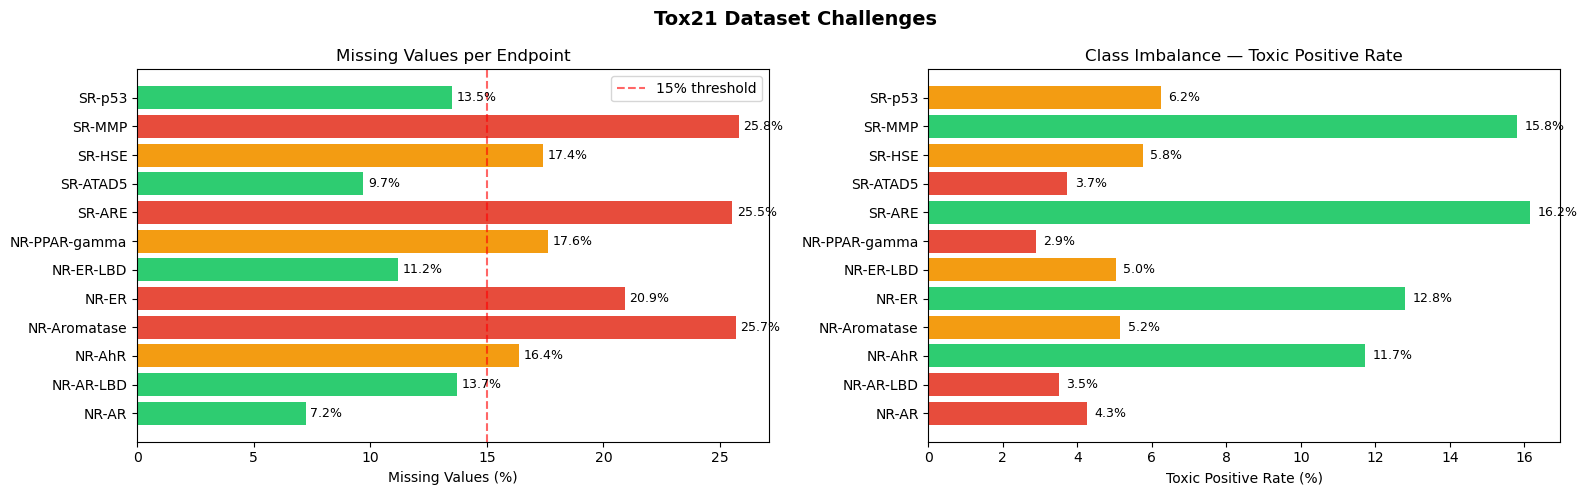

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
missing_pct = [df[ep].isna().mean()*100 for ep in TOX21_ENDPOINTS]
pos_pct = []
for ep in TOX21_ENDPOINTS:
    y = df[ep].dropna()
    pos_pct.append((y == 1).mean()*100)

colors_missing = ['#e74c3c' if x > 20 else '#f39c12' if x > 15 else '#2ecc71' for x in missing_pct]
colors_pos = ['#e74c3c' if x < 5 else '#f39c12' if x < 8 else '#2ecc71' for x in pos_pct]

axes[0].barh(TOX21_ENDPOINTS, missing_pct, color=colors_missing)
axes[0].axvline(15, linestyle='--', color='red', alpha=.6, label='15% threshold')
axes[0].set_title('Missing Values per Endpoint')
axes[0].set_xlabel('Missing Values (%)')
axes[0].legend()
for i, v in enumerate(missing_pct): axes[0].text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=9)

axes[1].barh(TOX21_ENDPOINTS, pos_pct, color=colors_pos)
axes[1].set_title('Class Imbalance — Toxic Positive Rate')
axes[1].set_xlabel('Toxic Positive Rate (%)')
for i, v in enumerate(pos_pct): axes[1].text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Tox21 Dataset Challenges', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

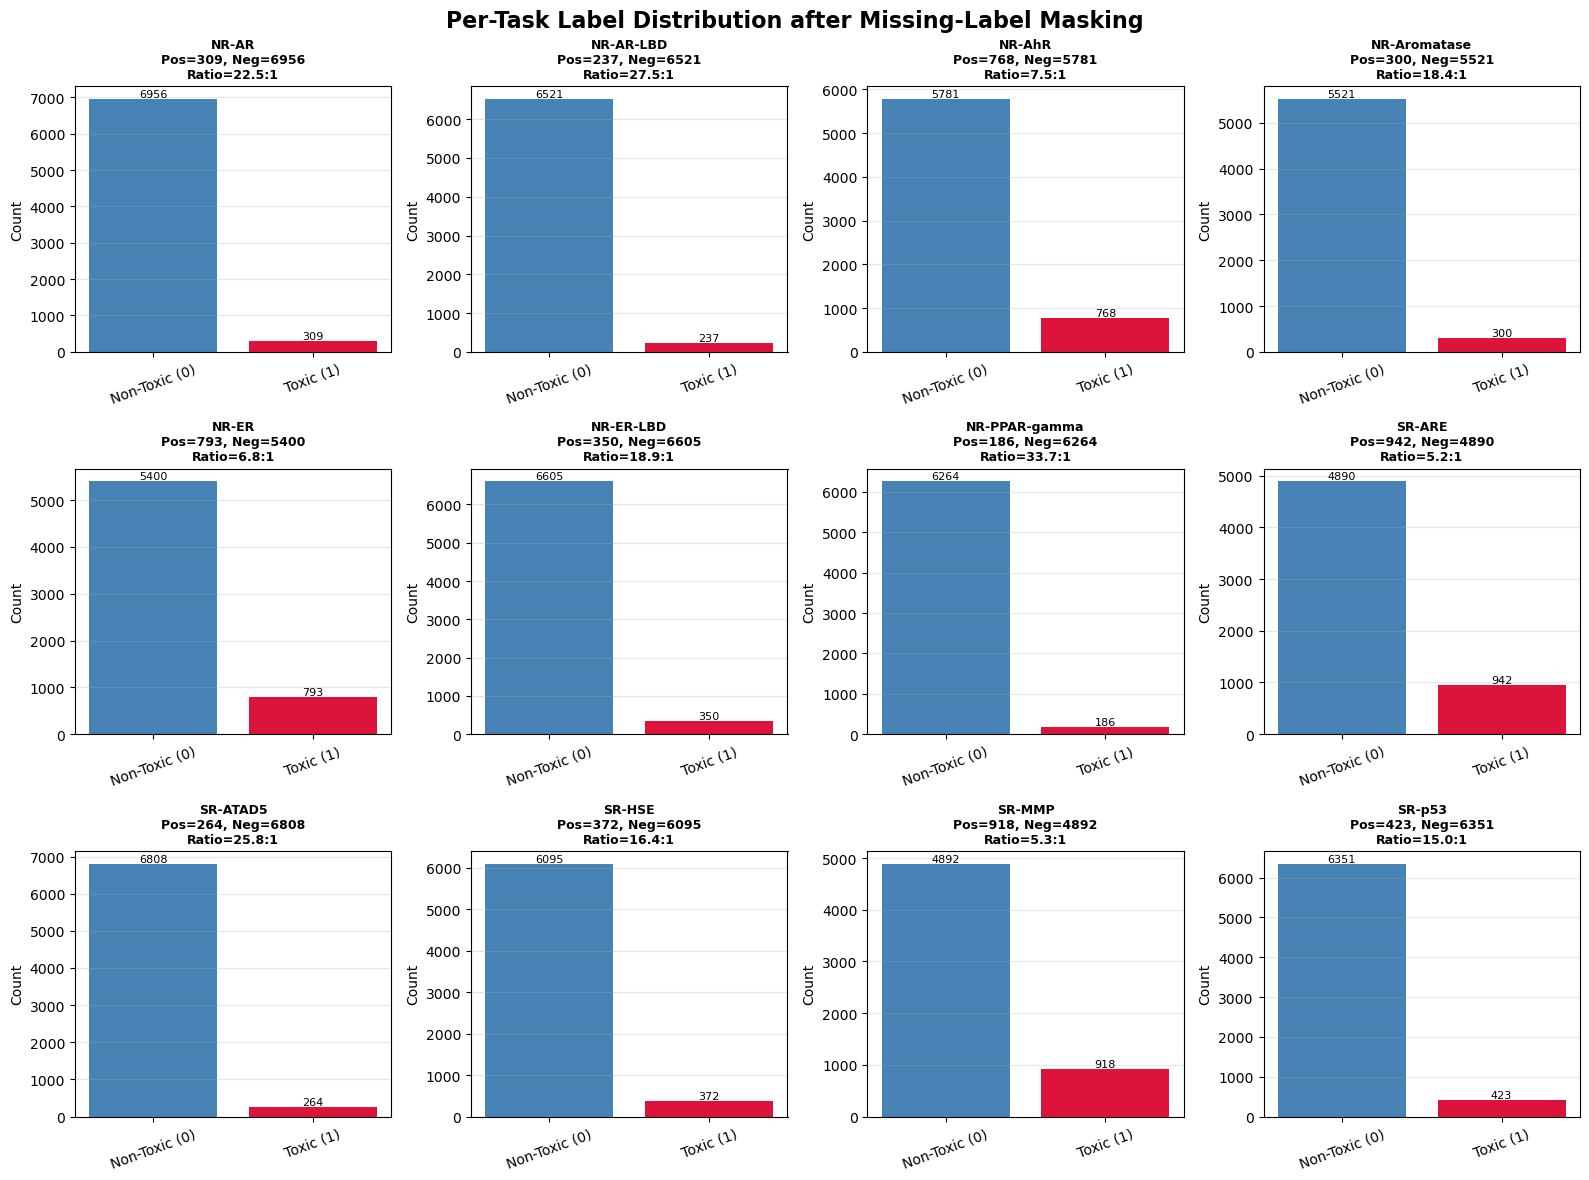

In [28]:
# ==========================================================
# Per-Task Label Distribution after Missing-Label Masking
# ==========================================================

import math
import matplotlib.pyplot as plt

n_cols = 4
n_rows = math.ceil(len(TARGET_COLS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.ravel()

for i, task in enumerate(TARGET_COLS):

    # Remove missing labels
    y_valid = df_raw[task].dropna().astype(int)

    # Count positive & negative samples
    n_neg = int((y_valid == 0).sum())
    n_pos = int((y_valid == 1).sum())

    # Plot
    axes[i].bar(
        ["Non-Toxic (0)", "Toxic (1)"],
        [n_neg, n_pos],
        color=["steelblue", "crimson"]
    )

    # Title
    axes[i].set_title(
        f"{task}\nPos={n_pos}, Neg={n_neg}\nRatio={n_neg/max(n_pos,1):.1f}:1",
        fontsize=9,
        fontweight="bold"
    )

    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", alpha=0.30)

    # Value labels
    axes[i].text(
        0, n_neg,
        str(n_neg),
        ha="center",
        va="bottom",
        fontsize=8
    )

    axes[i].text(
        1, n_pos,
        str(n_pos),
        ha="center",
        va="bottom",
        fontsize=8
    )

    axes[i].tick_params(axis="x", labelrotation=20)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Per-Task Label Distribution after Missing-Label Masking",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 4. Chemical preprocessing with RDKit

Best-output এর জন্য SMILES standardization করা হচ্ছে: invalid SMILES remove, largest fragment, normalization, uncharge, sanitize, canonical SMILES।

In [29]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize

normalizer = rdMolStandardize.Normalizer()
uncharger = rdMolStandardize.Uncharger()
fragment_chooser = rdMolStandardize.LargestFragmentChooser()

def standardize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None, None
        mol = fragment_chooser.choose(mol)
        mol = normalizer.normalize(mol)
        mol = uncharger.uncharge(mol)
        Chem.SanitizeMol(mol)
        can = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
        return can, mol
    except Exception:
        return None, None

std_smiles, mols = [], []
for s in df['smiles']:
    cs, m = standardize_smiles(s)
    std_smiles.append(cs)
    mols.append(m)

df['canonical_smiles'] = std_smiles
df['mol'] = mols

before = len(df)
df = df[df['mol'].notna()].copy()
invalid_removed = before - len(df)

before_dup = len(df)
df = df.drop_duplicates('canonical_smiles').reset_index(drop=True)
dups_removed = before_dup - len(df)

print(f'Invalid SMILES removed: {invalid_removed}')
print(f'Duplicate canonical SMILES removed: {dups_removed}')
print('Clean dataset shape:', df.shape)

Invalid SMILES removed: 9
Duplicate canonical SMILES removed: 211
Clean dataset shape: (7611, 16)


## 5. Show one cleaned molecule

এটি শুধু sanity check — SMILES থেকে molecule drawing ঠিক আছে কিনা দেখা।

Canonical SMILES: CCOc1ccc2nc(S(N)(=O)=O)sc2c1


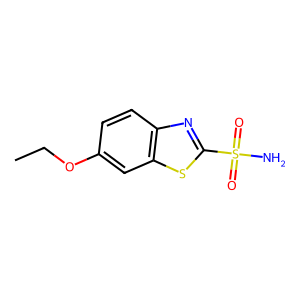

In [6]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

sample_smiles = df['canonical_smiles'].iloc[0]
print('Canonical SMILES:', sample_smiles)

mol = Chem.MolFromSmiles(sample_smiles)
drawer = rdMolDraw2D.MolDraw2DSVG(300, 300)
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
SVG(drawer.GetDrawingText())

## 6. Feature engineering: Morgan ECFP4 + MACCS + RDKit descriptors

Classical ML and hybrid models এই chemical features ব্যবহার করবে।

In [7]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=CONFIG['morgan_radius'], fpSize=CONFIG['morgan_bits']
)

def morgan_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp, dtype=np.int8)

def maccs_fp(mol):
    fp = MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp, dtype=np.int8)

X_morgan = np.vstack([morgan_fp(m) for m in df['mol']])
X_maccs = np.vstack([maccs_fp(m) for m in df['mol']])

print('Morgan shape:', X_morgan.shape)
print('MACCS shape:', X_maccs.shape)

Morgan shape: (7611, 2048)
MACCS shape: (7611, 167)


In [8]:
desc_names = [name for name, func in Descriptors.descList]
desc_funcs = [func for name, func in Descriptors.descList]

def rdkit_descriptor_vector(mol):
    vals = []
    for func in desc_funcs:
        try:
            v = func(mol)
            vals.append(v if np.isfinite(v) else np.nan)
        except Exception:
            vals.append(np.nan)
    return vals

X_desc = np.array([rdkit_descriptor_vector(m) for m in df['mol']], dtype=float)
print('RDKit descriptor shape:', X_desc.shape)

RDKit descriptor shape: (7611, 217)


## 7. Dataset split: 75% train / 25% test

এখানে dataset দুই ভাগে ভাগ করা হবে। Test set untouched থাকবে।

In [ ]:
Y = df[TOX21_ENDPOINTS].values.astype(float)

# Stratification helper: number of known toxic endpoints per molecule.
pos_count = np.nansum(Y == 1, axis=1)
labeled_count = np.sum(~np.isnan(Y), axis=1)
strat_key = pd.Series(pos_count).astype(int).astype(str) + '_' + pd.Series(labeled_count).clip(0, 12).astype(int).astype(str)

# Rare stratification groups fallback.
counts = strat_key.value_counts()
stratify_candidate = strat_key.copy()
rare_mask = stratify_candidate.map(counts) < 2
stratify_candidate[rare_mask] = 'rare_group'
stratify = stratify_candidate if stratify_candidate.value_counts().min() >= 2 else None
try:
    train_idx, test_idx = train_test_split(
        np.arange(len(df)), test_size=CONFIG['test_size'], random_state=RANDOM_STATE, stratify=stratify
    )
except Exception:
    train_idx, test_idx = train_test_split(
        np.arange(len(df)), test_size=CONFIG['test_size'], random_state=RANDOM_STATE
    )

print('বাংলা বার্তা: Dataset এখন ২ ভাগে ভাগ করা হয়েছে — 75% Train এবং 25% Test।')
print(f'Train molecules: {len(train_idx)} ({len(train_idx)/len(df)*100:.1f}%)')
print(f'Test molecules : {len(test_idx)} ({len(test_idx)/len(df)*100:.1f}%)')

## 8. Train-only imputation and scaling

Data leakage avoid করতে imputer/scaler শুধু train set-এ fit করা হয়েছে।

In [ ]:
X_fp = np.hstack([X_morgan, X_maccs]).astype(np.float32)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_desc_train = imputer.fit_transform(X_desc[train_idx])
X_desc_test = imputer.transform(X_desc[test_idx])

X_desc_train = scaler.fit_transform(X_desc_train)
X_desc_test = scaler.transform(X_desc_test)

X_chem_train = np.hstack([X_fp[train_idx], X_desc_train]).astype(np.float32)
X_chem_test = np.hstack([X_fp[test_idx], X_desc_test]).astype(np.float32)

Y_train = Y[train_idx]
Y_test = Y[test_idx]

smiles_train = df['canonical_smiles'].iloc[train_idx].tolist()
smiles_test = df['canonical_smiles'].iloc[test_idx].tolist()

print('Chemical train features:', X_chem_train.shape)
print('Chemical test features :', X_chem_test.shape)

## 9. Evaluation helper functions

Metrics: **AUC-ROC, Accuracy, Balanced Accuracy, F1-score**। Missing labels ignore করা হবে।

In [ ]:
def safe_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan

def evaluate_multitask_predictions(Y_true, P, threshold=0.5, model_name='Model'):
    rows = []
    for j, ep in enumerate(TOX21_ENDPOINTS):
        mask = ~np.isnan(Y_true[:, j])
        if mask.sum() == 0:
            continue
        y = Y_true[mask, j].astype(int)
        p = P[mask, j]
        pred = (p >= threshold).astype(int)
        rows.append({
            'Model': model_name,
            'Endpoint': ep,
            'n': int(mask.sum()),
            'n_pos': int((y == 1).sum()),
            'n_neg': int((y == 0).sum()),
            'AUC_ROC': safe_auc(y, p),
            'Accuracy': accuracy_score(y, pred),
            'Balanced_Accuracy': balanced_accuracy_score(y, pred),
            'F1': f1_score(y, pred, zero_division=0)
        })
    return pd.DataFrame(rows)

def summarize_result(endpoint_df):
    return {
        'Model': endpoint_df['Model'].iloc[0],
        'Mean_AUC_ROC': endpoint_df['AUC_ROC'].mean(),
        'Mean_Accuracy': endpoint_df['Accuracy'].mean(),
        'Mean_Balanced_Accuracy': endpoint_df['Balanced_Accuracy'].mean(),
        'Mean_F1': endpoint_df['F1'].mean()
    }

all_endpoint_results = []
all_model_summaries = []
all_predictions = {}

def register_model_result(name, endpoint_df, pred_matrix):
    all_endpoint_results.append(endpoint_df)
    all_model_summaries.append(summarize_result(endpoint_df))
    all_predictions[name] = pred_matrix
    print(endpoint_df[['Endpoint','AUC_ROC','Accuracy','Balanced_Accuracy','F1']].round(3).to_string(index=False))
    print('\nMean:', pd.Series(summarize_result(endpoint_df)).to_string())

## 10. Classical ML training helper

প্রতিটি endpoint আলাদা binary classification হিসেবে train হবে, এবং missing labels বাদ যাবে।

In [ ]:
def train_per_endpoint_model(model_factory, Xtr, Ytr, Xte, name):
    P = np.full((Xte.shape[0], len(TOX21_ENDPOINTS)), np.nan, dtype=float)
    fitted = {}
    for j, ep in enumerate(TOX21_ENDPOINTS):
        mask = ~np.isnan(Ytr[:, j])
        y = Ytr[mask, j].astype(int)
        if len(np.unique(y)) < 2:
            continue
        model = model_factory(y)
        model.fit(Xtr[mask], y)
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(Xte)[:, 1]
        else:
            score = model.decision_function(Xte)
            prob = 1 / (1 + np.exp(-score))
        P[:, j] = prob
        fitted[ep] = model
    result = evaluate_multitask_predictions(Y_test, P, model_name=name)
    return fitted, P, result

## 11. Model 1 — Random Forest

Strong classical baseline with class imbalance handling।

In [ ]:
def rf_factory(y):
    return RandomForestClassifier(
        n_estimators=350, max_depth=None, min_samples_leaf=2,
        class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE
    )

rf_models, rf_pred, rf_result = train_per_endpoint_model(rf_factory, X_chem_train, Y_train, X_chem_test, 'Random Forest')
register_model_result('Random Forest', rf_result, rf_pred)

## 12. Model 2 — Extra Trees

Random Forest-এর alternative ensemble, অনেক সময় sparse fingerprint feature-এ ভালো কাজ করে।

In [ ]:
def et_factory(y):
    return ExtraTreesClassifier(
        n_estimators=350, max_depth=None, min_samples_leaf=2,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
    )

et_models, et_pred, et_result = train_per_endpoint_model(et_factory, X_chem_train, Y_train, X_chem_test, 'Extra Trees')
register_model_result('Extra Trees', et_result, et_pred)

## 13. Model 3 — XGBoost

Imbalanced endpoints-এ `scale_pos_weight` use করা হয়েছে।

In [ ]:
try:
    from xgboost import XGBClassifier
    def xgb_factory(y):
        n_pos = max((y == 1).sum(), 1)
        n_neg = max((y == 0).sum(), 1)
        return XGBClassifier(
            n_estimators=350, max_depth=5, learning_rate=0.035,
            subsample=0.85, colsample_bytree=0.85,
            eval_metric='logloss', tree_method='hist',
            scale_pos_weight=n_neg / n_pos,
            random_state=RANDOM_STATE, n_jobs=-1
        )
    xgb_models, xgb_pred, xgb_result = train_per_endpoint_model(xgb_factory, X_chem_train, Y_train, X_chem_test, 'XGBoost')
    register_model_result('XGBoost', xgb_result, xgb_pred)
except Exception as e:
    print('XGBoost skipped:', e)

## 14. Model 4 — LightGBM

Fast gradient boosting model; class imbalance handle করা হয়েছে।

In [ ]:
try:
    from lightgbm import LGBMClassifier
    def lgb_factory(y):
        n_pos = max((y == 1).sum(), 1)
        n_neg = max((y == 0).sum(), 1)
        return LGBMClassifier(
            n_estimators=450, learning_rate=0.03, num_leaves=31,
            subsample=0.85, colsample_bytree=0.85,
            scale_pos_weight=n_neg / n_pos,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )
    lgb_models, lgb_pred, lgb_result = train_per_endpoint_model(lgb_factory, X_chem_train, Y_train, X_chem_test, 'LightGBM')
    register_model_result('LightGBM', lgb_result, lgb_pred)
except Exception as e:
    print('LightGBM skipped:', e)

## 15. Model 5 — SVM RBF

তোমার decision অনুযায়ী Linear SVM বাদ দিয়ে **RBF SVM** use করা হয়েছে। এটি slower হলেও non-linear decision boundary ধরতে পারে।

In [ ]:
def svm_rbf_factory(y):
    return SVC(
        kernel='rbf', C=4.0, gamma='scale', probability=True,
        class_weight='balanced', cache_size=1500, random_state=RANDOM_STATE
    )

svm_models, svm_pred, svm_result = train_per_endpoint_model(svm_rbf_factory, X_chem_train, Y_train, X_chem_test, 'SVM RBF')
register_model_result('SVM RBF', svm_result, svm_pred)

## 16. 3-fold cross-validation helper

CV শুধু train set-এ হবে। Test set final evaluation এর জন্য untouched থাকবে।

In [ ]:
def cv_mean_auc(model_factory, X, Y, model_name, n_splits=3):
    fold_scores = []
    # Use a stable stratification based on positive endpoint count.
    pos_count_train = np.nansum(Y == 1, axis=1).astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    try:
        split_iter = list(skf.split(X, pos_count_train))
    except Exception:
        from sklearn.model_selection import KFold
        split_iter = list(KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE).split(X))
    for fold, (tr, va) in enumerate(split_iter, 1):
        P = np.full((len(va), len(TOX21_ENDPOINTS)), np.nan)
        for j, ep in enumerate(TOX21_ENDPOINTS):
            mask_tr = ~np.isnan(Y[tr, j])
            mask_va = ~np.isnan(Y[va, j])
            ytr = Y[tr][mask_tr, j].astype(int)
            if len(np.unique(ytr)) < 2 or mask_va.sum() == 0:
                continue
            model = model_factory(ytr)
            model.fit(X[tr][mask_tr], ytr)
            if hasattr(model, 'predict_proba'):
                P[:, j] = model.predict_proba(X[va])[:, 1]
            else:
                s = model.decision_function(X[va])
                P[:, j] = 1 / (1 + np.exp(-s))
        fold_df = evaluate_multitask_predictions(Y[va], P, model_name=model_name)
        fold_scores.append(fold_df['AUC_ROC'].mean())
        print(f'{model_name} | Fold {fold}: Mean AUC-ROC = {fold_scores[-1]:.4f}')
    return np.array(fold_scores, dtype=float)

In [ ]:
cv_rows = []
cv_model_factories = [
    ('Random Forest', rf_factory),
    ('Extra Trees', et_factory),
    ('SVM RBF', svm_rbf_factory),
]
if 'xgb_factory' in globals(): cv_model_factories.append(('XGBoost', xgb_factory))
if 'lgb_factory' in globals(): cv_model_factories.append(('LightGBM', lgb_factory))

for name, factory in cv_model_factories:
    scores = cv_mean_auc(factory, X_chem_train, Y_train, name, CONFIG['n_splits_cv'])
    cv_rows.append({'Model': name, 'CV_Mean_AUC_ROC': np.nanmean(scores), 'CV_STD': np.nanstd(scores)})

cv_summary = pd.DataFrame(cv_rows).sort_values('CV_Mean_AUC_ROC', ascending=False)
print(cv_summary.round(4).to_string(index=False))

In [ ]:
plt.figure(figsize=(12, 5))
plot_df = cv_summary.sort_values('CV_Mean_AUC_ROC', ascending=False)
plt.bar(plot_df['Model'], plot_df['CV_Mean_AUC_ROC'], yerr=plot_df['CV_STD'], capsize=4)
plt.title('3-Fold Cross-Validation — Mean AUC-ROC')
plt.ylabel('Mean ROC-AUC')
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(plot_df['CV_Mean_AUC_ROC']):
    plt.text(i, v + 0.015, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 17. Deep Learning setup

TensorFlow পাওয়া গেলে DeepTox-style DNN, CapsNet, DenseNet model run হবে।

In [ ]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(RANDOM_STATE)
    print('TensorFlow version:', tf.__version__)
    TF_AVAILABLE = True
except Exception as e:
    TF_AVAILABLE = False
    print('TensorFlow not available. Deep learning cells will be skipped:', e)

In [ ]:
def make_y_and_sample_weight(Ymat):
    y_filled = np.nan_to_num(Ymat, nan=0.0).astype(np.float32)
    mask = (~np.isnan(Ymat)).astype(np.float32)
    sw = mask.copy()
    for j in range(Ymat.shape[1]):
        yj = Ymat[:, j]
        valid = ~np.isnan(yj)
        pos = max((yj[valid] == 1).sum(), 1)
        neg = max((yj[valid] == 0).sum(), 1)
        pos_weight = min(neg / pos, 30.0)
        sw[:, j] = mask[:, j] * np.where(y_filled[:, j] == 1, pos_weight, 1.0)
    return y_filled, sw.astype(np.float32)

y_train_dl, sw_train_dl = make_y_and_sample_weight(Y_train)
y_test_dl, sw_test_dl = make_y_and_sample_weight(Y_test)

## 18. Deep model 1 — DeepTox-style Multitask DNN

12 endpoints একসাথে learn করবে এবং missing labels mask করা হবে।

In [ ]:
if TF_AVAILABLE and CONFIG['run_heavy_deep_models']:
    def build_deeptox(input_dim, n_tasks=12):
        inp = keras.Input(shape=(input_dim,))
        x = layers.BatchNormalization()(inp)
        x = layers.Dense(1024, activation='relu')(x)
        x = layers.Dropout(0.35)(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.20)(x)
        out = layers.Dense(n_tasks, activation='sigmoid', name='toxicity')(x)
        return keras.Model(inp, out)

    deeptox_model = build_deeptox(X_chem_train.shape[1], len(TOX21_ENDPOINTS))
    deeptox_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
    cb = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
    hist = deeptox_model.fit(
        X_chem_train, y_train_dl, sample_weight=sw_train_dl,
        validation_split=0.15, epochs=CONFIG['deep_epochs'], batch_size=CONFIG['batch_size'],
        callbacks=cb, verbose=1
    )
    deeptox_pred = deeptox_model.predict(X_chem_test, batch_size=256)
    deeptox_result = evaluate_multitask_predictions(Y_test, deeptox_pred, model_name='DeepTox-style DNN')
    register_model_result('DeepTox-style DNN', deeptox_result, deeptox_pred)
else:
    print('DeepTox-style DNN skipped. Set CONFIG["run_heavy_deep_models"] = True and install TensorFlow.')

## 19. Deep model 2 — Multitask CapsNet

CapsNet architecture minority sparse patterns ধরতে useful হতে পারে। এখানে compact capsule-inspired multitask version দেওয়া হলো।

In [ ]:
if TF_AVAILABLE and CONFIG['run_heavy_deep_models']:
    class CapsuleLayer(layers.Layer):
        def __init__(self, num_capsules, dim_capsules, routings=3, **kwargs):
            super().__init__(**kwargs)
            self.num_capsules = num_capsules
            self.dim_capsules = dim_capsules
            self.routings = routings
        def build(self, input_shape):
            self.W = self.add_weight(
                shape=(input_shape[-1], self.num_capsules * self.dim_capsules),
                initializer='glorot_uniform', trainable=True
            )
        def squash(self, s):
            norm = tf.norm(s, axis=-1, keepdims=True)
            return (norm**2 / (1 + norm**2)) * (s / (norm + 1e-8))
        def call(self, inputs):
            u = tf.matmul(inputs, self.W)
            u = tf.reshape(u, (-1, inputs.shape[1], self.num_capsules, self.dim_capsules))
            b = tf.zeros_like(u[..., 0])
            for _ in range(self.routings):
                c = tf.nn.softmax(b, axis=2)
                s = tf.reduce_sum(tf.expand_dims(c, -1) * u, axis=1)
                v = self.squash(s)
                b += tf.reduce_sum(u * tf.expand_dims(v, 1), axis=-1)
            return v

    def build_capsnet(input_dim, n_tasks=12):
        inp = keras.Input(shape=(input_dim,))
        x = layers.BatchNormalization()(inp)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.Dropout(0.25)(x)
        x = layers.Dense(16*32, activation='relu')(x)
        x = layers.Reshape((16, 32))(x)
        caps = CapsuleLayer(num_capsules=12, dim_capsules=16, routings=3, name='capsule_embedding')(x)
        flat = layers.Flatten(name='caps_flatten')(caps)
        x = layers.Dense(128, activation='relu')(flat)
        out = layers.Dense(n_tasks, activation='sigmoid', name='toxicity')(x)
        return keras.Model(inp, out)

    capsnet_model = build_capsnet(X_chem_train.shape[1], len(TOX21_ENDPOINTS))
    capsnet_model.compile(optimizer=keras.optimizers.Adam(7e-4), loss='binary_crossentropy')
    cb = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
    capsnet_model.fit(
        X_chem_train, y_train_dl, sample_weight=sw_train_dl,
        validation_split=0.15, epochs=CONFIG['deep_epochs'], batch_size=CONFIG['batch_size'],
        callbacks=cb, verbose=1
    )
    capsnet_pred = capsnet_model.predict(X_chem_test, batch_size=256)
    capsnet_result = evaluate_multitask_predictions(Y_test, capsnet_pred, model_name='Multitask CapsNet')
    register_model_result('Multitask CapsNet', capsnet_result, capsnet_pred)
else:
    print('CapsNet skipped. Set CONFIG["run_heavy_deep_models"] = True and install TensorFlow.')

## 20. ChemBERTa / SMILES Transformer learning

Raw SMILES থেকে contextual embedding learn করা হবে। Model/download unavailable হলে cell gracefully skip করবে।

In [ ]:
chemberta_train_emb = chemberta_test_emb = None
if CONFIG['run_chemberta']:
    try:
        import torch
        from transformers import AutoTokenizer, AutoModel
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model_name = 'DeepChem/ChemBERTa-77M-MLM'
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        chemberta = AutoModel.from_pretrained(model_name).to(device)
        chemberta.eval()

        def chemberta_embeddings(smiles_list, batch_size=64):
            embs = []
            with torch.no_grad():
                for i in range(0, len(smiles_list), batch_size):
                    batch = smiles_list[i:i+batch_size]
                    tok = tokenizer(batch, padding=True, truncation=True, max_length=160, return_tensors='pt').to(device)
                    out = chemberta(**tok).last_hidden_state[:, 0, :]
                    embs.append(out.cpu().numpy())
            return np.vstack(embs).astype(np.float32)

        chemberta_train_emb = chemberta_embeddings(smiles_train, batch_size=CONFIG['batch_size'])
        chemberta_test_emb = chemberta_embeddings(smiles_test, batch_size=CONFIG['batch_size'])
        print('ChemBERTa embeddings:', chemberta_train_emb.shape, chemberta_test_emb.shape)
    except Exception as e:
        print('ChemBERTa skipped. Reason:', e)
else:
    print('ChemBERTa skipped by CONFIG')

In [ ]:
if chemberta_train_emb is not None:
    # Transformer embedding + SVM RBF classifier
    chem_scaler = StandardScaler()
    X_cb_train = chem_scaler.fit_transform(chemberta_train_emb)
    X_cb_test = chem_scaler.transform(chemberta_test_emb)
    chemberta_svm_models, chemberta_svm_pred, chemberta_svm_result = train_per_endpoint_model(
        svm_rbf_factory, X_cb_train, Y_train, X_cb_test, 'ChemBERTa + SVM RBF'
    )
    register_model_result('ChemBERTa + SVM RBF', chemberta_svm_result, chemberta_svm_pred)
else:
    print('ChemBERTa classifier skipped')

## 21. GNN model — custom GCN/GAT-style multitask network

Molecule naturally graph হওয়ায় graph neural network useful। এখানে lightweight padded-graph GCN model দেওয়া হলো।

In [ ]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
    print('PyTorch version:', torch.__version__)
except Exception as e:
    TORCH_AVAILABLE = False
    print('PyTorch not available:', e)

In [ ]:
def atom_features(atom):
    atomic_nums = [1,6,7,8,9,15,16,17,35,53]
    z = atom.GetAtomicNum()
    onehot = [1 if z == a else 0 for a in atomic_nums]
    onehot.append(1 if z not in atomic_nums else 0)
    return onehot + [
        atom.GetDegree()/6,
        atom.GetFormalCharge()/4,
        float(atom.GetIsAromatic()),
        atom.GetTotalNumHs()/4
    ]

def mol_to_graph_arrays(mol, max_atoms=80):
    atoms = mol.GetAtoms()
    n = min(len(atoms), max_atoms)
    feat_dim = len(atom_features(atoms[0])) if n > 0 else 15
    Xg = np.zeros((max_atoms, feat_dim), dtype=np.float32)
    Ag = np.zeros((max_atoms, max_atoms), dtype=np.float32)
    for i in range(n):
        Xg[i] = atom_features(atoms[i])
        Ag[i, i] = 1.0
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if i < max_atoms and j < max_atoms:
            Ag[i, j] = Ag[j, i] = 1.0
    deg = Ag.sum(axis=1, keepdims=True)
    Ag = Ag / np.maximum(deg, 1.0)
    mask = np.zeros((max_atoms,), dtype=np.float32)
    mask[:n] = 1.0
    return Xg, Ag, mask

In [ ]:
gnn_pred = None
if TORCH_AVAILABLE and CONFIG['run_gnn'] and CONFIG['run_heavy_deep_models']:
    MAX_ATOMS = 80
    graph_data = [mol_to_graph_arrays(m, MAX_ATOMS) for m in df['mol']]
    Xg_all = np.stack([g[0] for g in graph_data])
    Ag_all = np.stack([g[1] for g in graph_data])
    Mg_all = np.stack([g[2] for g in graph_data])
    print('Graph arrays:', Xg_all.shape, Ag_all.shape)
else:
    print('GNN graph preparation skipped')

In [ ]:
if TORCH_AVAILABLE and CONFIG['run_gnn'] and CONFIG['run_heavy_deep_models']:
    class GraphDataset(Dataset):
        def __init__(self, idxs):
            self.idxs = idxs
        def __len__(self): return len(self.idxs)
        def __getitem__(self, k):
            i = self.idxs[k]
            y = np.nan_to_num(Y[i], nan=0.0).astype(np.float32)
            w = (~np.isnan(Y[i])).astype(np.float32)
            return Xg_all[i], Ag_all[i], Mg_all[i], y, w

    class SimpleGCN(nn.Module):
        def __init__(self, in_dim, hidden=96, tasks=12):
            super().__init__()
            self.lin1 = nn.Linear(in_dim, hidden)
            self.lin2 = nn.Linear(hidden, hidden)
            self.attn = nn.Linear(hidden, 1)
            self.out = nn.Linear(hidden, tasks)
        def forward(self, x, a, m):
            h = F.relu(self.lin1(torch.bmm(a, x)))
            h = F.relu(self.lin2(torch.bmm(a, h)))
            att = self.attn(h).squeeze(-1).masked_fill(m == 0, -1e9)
            att = torch.softmax(att, dim=1).unsqueeze(-1)
            pooled = torch.sum(h * att, dim=1)
            return torch.sigmoid(self.out(pooled))

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    gnn_model = SimpleGCN(Xg_all.shape[-1]).to(device)
    opt = torch.optim.Adam(gnn_model.parameters(), lr=1e-3, weight_decay=1e-5)
    loader = DataLoader(GraphDataset(train_idx), batch_size=64, shuffle=True)

    for epoch in range(CONFIG['deep_epochs']):
        gnn_model.train(); losses = []
        for x,a,m,y,w in loader:
            x,a,m,y,w = x.to(device), a.to(device), m.to(device), y.to(device), w.to(device)
            pred = gnn_model(x,a,m)
            loss = F.binary_cross_entropy(pred, y, reduction='none')
            loss = (loss * w).sum() / torch.clamp(w.sum(), min=1.0)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        print(f'GNN epoch {epoch+1}: loss={np.mean(losses):.4f}')

    gnn_model.eval(); preds = []
    test_loader = DataLoader(GraphDataset(test_idx), batch_size=128, shuffle=False)
    with torch.no_grad():
        for x,a,m,y,w in test_loader:
            p = gnn_model(x.to(device), a.to(device), m.to(device)).cpu().numpy()
            preds.append(p)
    gnn_pred = np.vstack(preds)
    gnn_result = evaluate_multitask_predictions(Y_test, gnn_pred, model_name='GNN GCN-GAT style')
    register_model_result('GNN GCN-GAT style', gnn_result, gnn_pred)
else:
    print('GNN skipped')

## 22. DenseNet121 feature extraction from 2D molecule images

SMILES → 2D molecule image → DenseNet121 embedding। এরপর SVM/RF hybrid classifier ব্যবহার করা হবে।

In [ ]:
densenet_train_emb = densenet_test_emb = None
if TF_AVAILABLE and CONFIG['run_densenet']:
    try:
        from rdkit.Chem import Draw
        from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
        from tensorflow.keras.preprocessing.image import img_to_array
        from PIL import Image

        IMG_SIZE = CONFIG['dense_image_size']
        try:
            densenet_base = DenseNet121(weights='imagenet', include_top=False, pooling='avg', input_shape=(IMG_SIZE, IMG_SIZE, 3))
        except Exception as e:
            print('ImageNet weights unavailable; using DenseNet121 weights=None:', e)
            densenet_base = DenseNet121(weights=None, include_top=False, pooling='avg', input_shape=(IMG_SIZE, IMG_SIZE, 3))

        def mol_to_img_array(mol, size=224):
            img = Draw.MolToImage(mol, size=(size, size)).convert('RGB')
            arr = img_to_array(img)
            return arr

        def densenet_embeddings(mols, batch_size=32):
            embs = []
            for i in range(0, len(mols), batch_size):
                batch_mols = mols[i:i+batch_size]
                arr = np.stack([mol_to_img_array(m, IMG_SIZE) for m in batch_mols]).astype(np.float32)
                arr = preprocess_input(arr)
                emb = densenet_base.predict(arr, verbose=0)
                embs.append(emb)
                del arr; gc.collect()
            return np.vstack(embs).astype(np.float32)

        densenet_train_emb = densenet_embeddings(df['mol'].iloc[train_idx].tolist(), batch_size=32)
        densenet_test_emb = densenet_embeddings(df['mol'].iloc[test_idx].tolist(), batch_size=32)
        print('DenseNet embeddings:', densenet_train_emb.shape, densenet_test_emb.shape)
    except Exception as e:
        print('DenseNet121 skipped:', e)
else:
    print('DenseNet skipped by CONFIG or TensorFlow unavailable')

## 23. Hybrid model — DenseNet121 + SVM RBF

2D image embedding-এর উপর RBF SVM train করা হবে।

In [ ]:
if densenet_train_emb is not None:
    den_scaler = StandardScaler()
    X_den_train = den_scaler.fit_transform(densenet_train_emb)
    X_den_test = den_scaler.transform(densenet_test_emb)
    den_svm_models, den_svm_pred, den_svm_result = train_per_endpoint_model(
        svm_rbf_factory, X_den_train, Y_train, X_den_test, 'DenseNet121 + SVM RBF'
    )
    register_model_result('DenseNet121 + SVM RBF', den_svm_result, den_svm_pred)
else:
    print('DenseNet121 + SVM RBF skipped')

## 24. Hybrid model — DenseNet121 + Random Forest

DenseNet image embedding-এর উপর Random Forest train করা হবে।

In [ ]:
if densenet_train_emb is not None:
    den_rf_models, den_rf_pred, den_rf_result = train_per_endpoint_model(
        rf_factory, X_den_train, Y_train, X_den_test, 'DenseNet121 + Random Forest'
    )
    register_model_result('DenseNet121 + Random Forest', den_rf_result, den_rf_pred)
else:
    print('DenseNet121 + Random Forest skipped')

## 25. Hybrid model — DenseNet121 + chemical features + SVM RBF

Image representation এবং chemical fingerprint/descriptor একসাথে combine করা হয়েছে।

In [ ]:
if densenet_train_emb is not None:
    X_denchem_train = np.hstack([X_chem_train, X_den_train]).astype(np.float32)
    X_denchem_test = np.hstack([X_chem_test, X_den_test]).astype(np.float32)
    denchem_svm_models, denchem_svm_pred, denchem_svm_result = train_per_endpoint_model(
        svm_rbf_factory, X_denchem_train, Y_train, X_denchem_test, 'DenseNet121 + Chemical + SVM RBF'
    )
    register_model_result('DenseNet121 + Chemical + SVM RBF', denchem_svm_result, denchem_svm_pred)
else:
    print('DenseNet121 + Chemical + SVM RBF skipped')

## 26. Hybrid model — CapsNet embedding + SVM RBF

Trained CapsNet থেকে embedding নিয়ে SVM RBF classifier।

In [ ]:
if 'capsnet_model' in globals():
    try:
        cap_embed_model = keras.Model(capsnet_model.input, capsnet_model.get_layer('caps_flatten').output)
        cap_train_emb = cap_embed_model.predict(X_chem_train, batch_size=256)
        cap_test_emb = cap_embed_model.predict(X_chem_test, batch_size=256)
        cap_scaler = StandardScaler()
        X_cap_train = cap_scaler.fit_transform(cap_train_emb)
        X_cap_test = cap_scaler.transform(cap_test_emb)

        cap_svm_models, cap_svm_pred, cap_svm_result = train_per_endpoint_model(
            svm_rbf_factory, X_cap_train, Y_train, X_cap_test, 'CapsNet Embedding + SVM RBF'
        )
        register_model_result('CapsNet Embedding + SVM RBF', cap_svm_result, cap_svm_pred)
    except Exception as e:
        print('CapsNet + SVM skipped:', e)
else:
    print('CapsNet model not available; CapsNet + SVM skipped')

## 27. Hybrid model — CapsNet embedding + Random Forest

CapsNet learned representation-এর উপর Random Forest।

In [ ]:
if 'X_cap_train' in globals():
    cap_rf_models, cap_rf_pred, cap_rf_result = train_per_endpoint_model(
        rf_factory, X_cap_train, Y_train, X_cap_test, 'CapsNet Embedding + Random Forest'
    )
    register_model_result('CapsNet Embedding + Random Forest', cap_rf_result, cap_rf_pred)
else:
    print('CapsNet embedding not available; CapsNet + RF skipped')

## 28. Soft Voting Ensemble

Best output-এর জন্য available models-এর probability average করা হবে।

In [ ]:
ensemble_candidates = [
    'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'SVM RBF',
    'DeepTox-style DNN', 'Multitask CapsNet', 'GNN GCN-GAT style',
    'ChemBERTa + SVM RBF', 'DenseNet121 + SVM RBF', 'DenseNet121 + Random Forest',
    'DenseNet121 + Chemical + SVM RBF', 'CapsNet Embedding + SVM RBF', 'CapsNet Embedding + Random Forest'
]

available = [name for name in ensemble_candidates if name in all_predictions]
print('Ensemble available models:', available)

if len(available) >= 2:
    stack = np.stack([all_predictions[name] for name in available], axis=0)
    ensemble_pred = np.nanmean(stack, axis=0)
    ensemble_result = evaluate_multitask_predictions(Y_test, ensemble_pred, model_name='Soft Voting Ensemble')
    register_model_result('Soft Voting Ensemble', ensemble_result, ensemble_pred)
else:
    print('Not enough models for ensemble')

## 29. Final leaderboard

Final test set-এ সব available model compare করা হবে।

In [ ]:
leaderboard = pd.DataFrame(all_model_summaries).sort_values('Mean_AUC_ROC', ascending=False).reset_index(drop=True)
print(leaderboard.round(4).to_string(index=False))

In [ ]:
if len(leaderboard):
    plt.figure(figsize=(12, 5))
    plot_df = leaderboard.sort_values('Mean_AUC_ROC', ascending=True)
    plt.barh(plot_df['Model'], plot_df['Mean_AUC_ROC'])
    plt.title('Final Test Leaderboard — Mean AUC-ROC')
    plt.xlabel('Mean AUC-ROC across 12 endpoints')
    plt.xlim(0, 1.05)
    for i, v in enumerate(plot_df['Mean_AUC_ROC']):
        plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

## 30. AUC heatmap — models × endpoints

প্রতিটি model কোন endpoint-এ ভালো/খারাপ করছে সেটা heatmap-এ দেখা হবে।

In [ ]:
if len(all_endpoint_results):
    endpoint_all = pd.concat(all_endpoint_results, ignore_index=True)
    heat = endpoint_all.pivot_table(index='Endpoint', columns='Model', values='AUC_ROC')
    plt.figure(figsize=(max(12, len(heat.columns)*0.9), 6))
    im = plt.imshow(heat.values, aspect='auto', vmin=0.5, vmax=1.0)
    plt.colorbar(im, label='ROC-AUC')
    plt.xticks(range(len(heat.columns)), heat.columns, rotation=35, ha='right')
    plt.yticks(range(len(heat.index)), heat.index)
    plt.title('AUC Heatmap — All Models × Tox21 Endpoints')
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]
            if np.isfinite(val):
                plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

## 31. Confusion matrices — best model vs hardest endpoint

Best model নিয়ে easiest/highest AUC endpoint এবং hardest/most imbalanced endpoint compare করা হবে।

In [ ]:
if len(leaderboard):
    best_name = leaderboard.iloc[0]['Model']
    Pbest = all_predictions[best_name]
    best_endpoint_df = pd.concat(all_endpoint_results).query('Model == @best_name').copy()
    easiest_ep = best_endpoint_df.sort_values('AUC_ROC', ascending=False).iloc[0]['Endpoint']
    hardest_ep = 'NR-PPAR-gamma' if 'NR-PPAR-gamma' in TOX21_ENDPOINTS else best_endpoint_df.sort_values('AUC_ROC').iloc[0]['Endpoint']

    def plot_cm(ax, ep):
        j = TOX21_ENDPOINTS.index(ep)
        mask = ~np.isnan(Y_test[:, j])
        y = Y_test[mask, j].astype(int)
        pred = (Pbest[mask, j] >= 0.5).astype(int)
        cm = confusion_matrix(y, pred, labels=[0,1])
        ax.imshow(cm, cmap='Blues')
        ax.set_title(f'{ep}\nBest model: {best_name}')
        ax.set_xticks([0,1]); ax.set_xticklabels(['Non-Toxic','Toxic'])
        ax.set_yticks([0,1]); ax.set_yticklabels(['Non-Toxic','Toxic'])
        ax.set_xlabel('Predicted label'); ax.set_ylabel('True label')
        for r in range(2):
            for c in range(2):
                ax.text(c, r, str(cm[r,c]), ha='center', va='center', fontsize=12)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    plot_cm(axes[0], easiest_ep)
    plot_cm(axes[1], hardest_ep)
    plt.suptitle('Confusion Matrices — Best vs Hardest Tox21 Endpoint', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 32. Save results

Prediction summaries CSV হিসেবে save করা হবে।

In [ ]:
OUT_DIR = 'tox21_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

if len(leaderboard):
    leaderboard.to_csv(os.path.join(OUT_DIR, 'tox21_model_leaderboard.csv'), index=False)
if len(all_endpoint_results):
    pd.concat(all_endpoint_results, ignore_index=True).to_csv(os.path.join(OUT_DIR, 'tox21_endpoint_results.csv'), index=False)
if 'cv_summary' in globals():
    cv_summary.to_csv(os.path.join(OUT_DIR, 'tox21_3fold_cv_summary.csv'), index=False)

print('Saved outputs inside:', OUT_DIR)

# Research notes

- Missing labels কখনো 0/1 হিসেবে impute করা হয়নি।
- Chemical preprocessing সব model-এর আগে করা হয়েছে।
- Test set 25% untouched রাখা হয়েছে।
- 3-fold CV train set-এর উপর করা হয়েছে।
- Heavy models GPU ছাড়া slow হতে পারে। প্রয়োজনে `CONFIG['run_heavy_deep_models'] = False` করে classical + hybrid subset run করা যাবে।